### Task 5: Singular Value Decomposition (SVD) for Eigenfaces
#### **Objective**
In this task, you will use SVD to compute the eigenfaces of a dataset and analyze how well the faces are recovered when incorporating more ranks to the approximation of the matrix $X$.

#### **Overview**
Singular Value Decomposition factorizes a matrix $X$ (typically mean-centered) into three matrices: $X = U \Sigma V^T$. For this exercise, we define $X$ as an $n \times m$ matrix, where $n$ is the number of features (pixels) and $m$ is the number of samples (images). The columns of $U$ are the **eigenfaces** (principal components). By truncating these matrices to the top $k$ components, we can reconstruct a rank-k approximation of the original dataset: $X_k = U_k \Sigma_k V_k^T$.

Your objective is to complete the `EigenfacesSVD` class steps to compute the SVD, reconstruct faces, and calculate both cumulative explained variance and reconstruction-error.

---

#### **SubTasks**

##### **SubTask 1: Compute SVD**
- **Function to complete**: `fit(self, X)`
- **Purpose**: Mean-center the data and compute the SVD.
- **Steps**:
  1. Compute the mean face (mean across all samples, `axis=1` since samples are columns). To allow broadcasting, ensure its shape is `(n, 1)` by setting `keepdims=True` in your mean calculation.
  2. Subtract the mean face from `X` to get centered data.
  3. Compute SVD on the centered data using `np.linalg.svd(..., full_matrices=False)`.
  4. Store the components in `self.U, self.S, self.Vt` and `self.mean_face`.

##### **SubTask 2: Rank-k approximation of X**
- **Function to complete**: `rank_k_approximation(self, k)`
- **Purpose**: Reconstruct the dataset of faces using only the top `k` principal components. This is the rank-k approxiamtion of our data.
- **Steps**:
  1. To reconstruct the data using the first $k$ components is to iteratively add the outer products between the $i$-th eigenface (column of $U$) with the $i$-th row of $V^T$, multiplied the $i$-th singular value.
  2. Initialize an empty array for the reconstructed data `X_reconstructed` of the same shape as `X` but filled with zeros.
  3. Use a loop up to `k` to add the rank one matrices `np.outer(self.U[:, i], self.Vt[i, :]) * self.S[i]` to `X_reconstructed`.
  4. Finally, add `self.mean_face` back to `X_reconstructed`.

##### **SubTask 3: Cumulative Explained Variance**
- **Function to complete**: `cumulative_explained_variance(self)`
- **Purpose**: Compute the cumulative variance explained by the singular values.
- **Steps**:
  1. The variance explained by each singular value is proportional to its square.
  2. Calculate the cumulative sum of the variance.
  3. Divide by the total sum of squared singular values to get the ratio.

##### **SubTask 4: Reconstruction error (training matrix, from SVD factors)**
  In this subtask you will quantify how much information is lost when we keep only the first $k$ singular components.
- **Function to complete**: `reconstruction_error(self, k)`

  Recall that after fitting SVD on the **mean-centered training matrix** $X \in \mathbb{R}^{n \times m}$, we have
  $$
  X = U S V^\top,
  $$
  where $U \in \mathbb{R}^{n\times r}$, $S \in \mathbb{R}^{r\times r}$ (diagonal), $V^\top \in \mathbb{R}^{r\times m}$, and $r = \mathrm{rank}(X)$.

  The rank-$k$ approximation is obtained by truncation:
  $$
  X_k = U_{[:,0:k]} \, S_{0:k,0:k} \, V^\top_{[0:k,:]}.
  $$

  **Important:** In this function you should **not** use the original data matrix directly. Instead, reconstruct the “full” training matrix using the SVD factors:
  $$
  X_{\text{full}} = U S V^\top,
  $$
  and compare it to the truncated reconstruction $X_k$.

  Define the reconstruction error as the mean squared error (MSE) between these two matrices:
  $$
  \mathrm{MSE}(k) = \frac{1}{nm}\|X_{\text{full}} - X_k\|_F^2
  = \frac{1}{nm}\sum_{i=1}^{n}\sum_{j=1}^{m}\left(X_{\text{full}}(i,j)-X_k(i,j)\right)^2.
  $$

  Implement `reconstruction_error(k)` so it:
  1. Computes $X_{\text{full}} = U S V^\top$,
  2. Computes $X_k$ using your rank-$k$ approximation routine,
  3. Returns the MSE $\mathrm{MSE}(k)$.

##### **SubTask 5: Dimensionality Reduction for Classification**
- **Function to complete**: There is nothing to complete here, you just have to run and see the results. You will train a very simple 5-NN classifier both on the raw data (full image) and the .
- **Purpose**: Compare classification accuracy of a 5-Nearest Neighbor classifier on the raw data vs. compressed data with less than 10% of features (k=70).
- **Steps**:
  1. Fit `EigenfacesSVD` on the training set.
  2. Project both the training and test sets onto the first 40 eigenfaces to obtain the weights. *Note: For scikit-learn models (like 5-NN), the samples must be organized as rows, so transpose the weights back to `(samples, features)` before fitting.*
  3. Train a 5-NN classifier on the raw training data and evaluate it on the raw test data.
  4. Train a 5-NN classifier on the compressed training data and evaluate it on the compressed test data.

In [3]:
import numpy as np

class EigenfacesSVD:
    """
    A class to perform SVD on image data (faces) to extract eigenfaces
    and reconstruct images.
    """
    def __init__(self):
        self.mean_face = None
        self.U = None
        self.S = None
        self.Vt = None

    def fit(self, X):
        """
        Computes the SVD of the mean-centered data.
        Assumes X is of shape (n_features, n_samples).
        """
        # --- YOUR CODE HERE ---
        # 1. Compute the mean face (mean along the sample axis)
        self.mean_face = np.mean(X, axis= 1, keepdims = True)

        # 2. Mean-center the data
        X_centered = X - self.mean_face

        # 3. Compute SVD of the centered data
        # Hint: Use np.linalg.svd with full_matrices=False
        self.U, self.S, self.Vt = np.linalg.svd(X_centered , full_matrices=False)

        # --- END YOUR CODE ---

        print("Shape of U:", self.U.shape)
        print("Shape of S:", self.S.shape)
        print("Shape of Vt:", self.Vt.shape)

    def rank_k_approximation(self, k):
        """
        Generates the rank-k approximation of X using the top k eigenfaces.
        Note: This specific reconstruction is meant for the training data where U, S, Vt
        are already computed. We reconstruct using the outer product of the first k components.
        """

        # --- STUDENT CODE HERE ---
        # 1. Initialize numpy matrix matching the shape of X filled with zeros (read the shape of X from U and V)
        X_reconstructed = np.zeros((self.U.shape[0], self.Vt.shape[1]))

        # 2. Iterate up to k, adding the outer product of the i-th column of U and i-th row of Vt,
        # scaled by the i-th singular value.
        for i in range(k):
            X_reconstructed +=self.S[i] * np.outer(self.U[:,i], self.Vt[i ,:])

        # 3. Add the mean face back
        X_reconstructed +=self.mean_face
        # --- END STUDENT CODE ---

        return X_reconstructed

    def reconstruct_dataset(self, X, k):
        """
        Reconstructs a given dataset of faces using the top k eigenfaces by projecting it to the eigenfaces base.
        """

        # 1. Mean-center the input data
        X_centered = X - self.mean_face

        # 2. Extract the top k eigenfaces (first k columns of U)
        U_k = self.U[:, :k]

        # 3. Project the centered data onto the top k eigenfaces to get the weights
        weights = U_k.T @ X_centered

        # 4. Reconstruct the faces using the weights and the top k eigenfaces, then add the mean face back
        X_reconstructed = (U_k @ weights) + self.mean_face

        return X_reconstructed

    def cumulative_explained_variance(self):
        """
        Computes the cumulative explained variance of the singular values.
        """
        # --- YOUR CODE HERE ---
        # 1. Compute the variance explained by each singular value (stored in self.S), which is proportional to the square of its value
        variance = self.S ** 2

        # 2. Calculate the cumulative sum of the variance using np.cumsum(). The value in the position k of this vector is proportional to the total variance explained by the rank k approximation.
        cumulative_variance = np.cumsum(variance)

        # 3. Normalize dividing by the total variance
        explained_variance_ratio = cumulative_variance / cumulative_variance[-1]
        # --- END YOUR CODE ---

        return explained_variance_ratio

    def reconstruction_error(self, k):
        """
        Computes the Mean Squared Error (MSE) of the rank-k approximation.
        """
        # --- YOUR CODE HERE ---
        # 1. Compute the original dataset form the U S and Vt matrices.
        # To match the n x m shape of X, we should take only the first m columns of U:
        m = self.Vt.shape[0]
        U_m = self.U[:,:m]
        # Observation: Notice that self.S is a vector, not a diagonal matrix.
        X_centered = U_m * self.S @ self.Vt

        # Add the mean face
        X_full = X_centered + self.mean_face

        # 2. Reconstruct X using k components
        X_approx = self.U[:, :k] * self.S[:k] @ self.Vt[:k, :] + self.mean_face

        # 3. Calculate the Mean Squared Error between original X and X_approx
        error = np.mean((X_full - X_approx) ** 2)
        # --- END YOUR CODE ---

        return error


### Verification
Let's test the implementation using the **Labeled Faces in the Wild (LFW)** dataset. We will visualize the eigenfaces, print the singular values, plot cumulative variance, and check the reconstruction visual and numerical error.

Dataset shape: (11750, 760) (Features: 11750, Samples: 760)
Shape of U: (11750, 760)
Shape of S: (760,)
Shape of Vt: (760, 760)

Visualizing the Mean Face and Top 11 Eigenfaces...


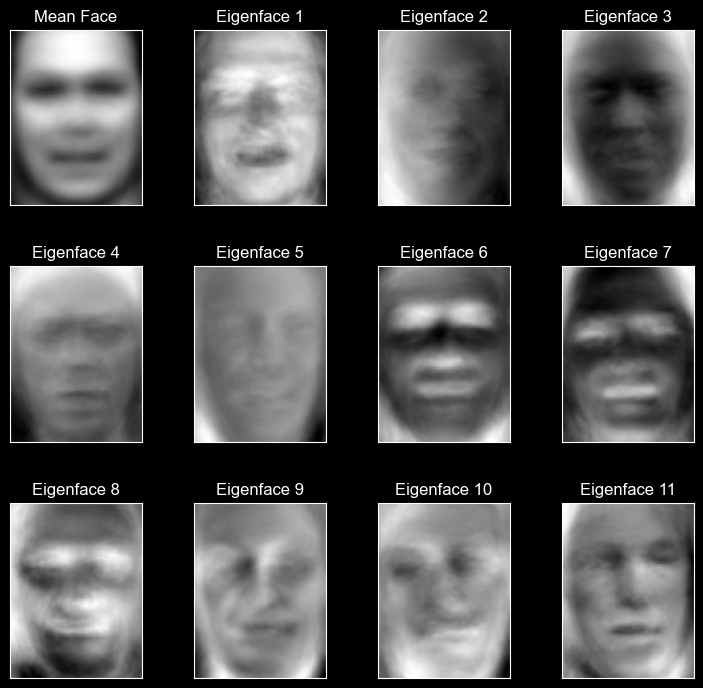

In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people

# 1. Load the LFW faces dataset
print("Downloading LFW faces dataset...")
min_faces_per_person = 40
lfw = fetch_lfw_people(min_faces_per_person=min_faces_per_person, resize=1.0)

# To keep the dataset balanced, we keep only the first N images per subject
X_balanced = []
y_balanced = []

for target in np.unique(lfw.target):
    indices = np.where(lfw.target == target)[0]
    selected_indices = indices[:min_faces_per_person]
    X_balanced.append(lfw.data[selected_indices])
    y_balanced.append(lfw.target[selected_indices])

X_data = np.vstack(X_balanced)
y = np.concatenate(y_balanced)

# Convert to shape (n_features, n_samples) to match X \in R^(n x m)
X = X_data.T
names = lfw.target_names

print(f"Dataset shape: {X.shape} (Features: {X.shape[0]}, Samples: {X.shape[1]})")

# 2. Initialize and fit the SVD model
ef_svd = EigenfacesSVD()
ef_svd.fit(X)

# 3. Extract and show the eigenfaces (reshaped for visualization)
n_row, n_col = lfw.images.shape[1], lfw.images.shape[2]

def plot_gallery(images, titles, h, w, n_rows=3, n_cols=4):
    plt.figure(figsize=(1.8 * n_cols, 2.4 * n_rows))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_rows * n_cols):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())

# Plot the Mean Face and the first 11 Eigenfaces
# The eigenfaces are the columns of the U matrix
eigenfaces = ef_svd.U.T.reshape((ef_svd.U.shape[1], n_row, n_col))
eigenface_titles = ["Mean Face"] + [f"Eigenface {i+1}" for i in range(11)]
images_to_plot = np.vstack([ef_svd.mean_face.reshape(1, n_row, n_col), eigenfaces[:11]])

print("\nVisualizing the Mean Face and Top 11 Eigenfaces...")
plot_gallery(images_to_plot, eigenface_titles, n_row, n_col)
plt.show()


### Plotting Singular Values and Reconstructions Analysis

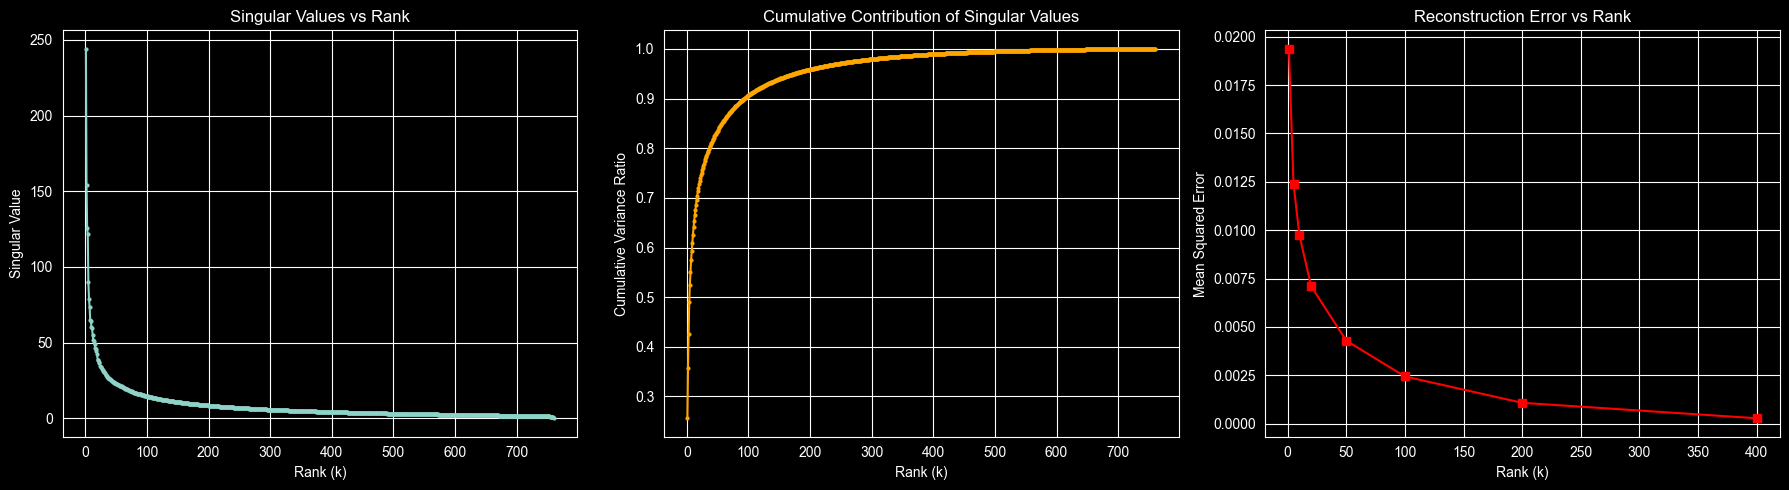

In [12]:
# ----------------------------------------------------
# Analyze singular values, variance, and error
# ----------------------------------------------------

singular_values = ef_svd.S
explained_variance = ef_svd.cumulative_explained_variance()
ranks = np.arange(1, len(singular_values) + 1)

# Compute reconstruction error for different ranks
target_ranks = [1, 5, 10, 20, 50, 100, 200, 400]
reconstruction_errors = [ef_svd.reconstruction_error(k) for k in target_ranks]

plt.figure(figsize=(18, 5))

# Plot 1: Singular Values
plt.subplot(1, 3, 1)
plt.plot(ranks, singular_values, marker='o', linestyle='-', markersize=2)
plt.xlabel('Rank (k)')
plt.ylabel('Singular Value')
plt.title('Singular Values vs Rank')
plt.grid(True)

# Plot 2: Cumulative Explained Variance
plt.subplot(1, 3, 2)
plt.plot(ranks, explained_variance, marker='o', linestyle='-', markersize=2, color='orange')
plt.xlabel('Rank (k)')
plt.ylabel('Cumulative Variance Ratio')
plt.title('Cumulative Contribution of Singular Values')
plt.grid(True)

# Plot 3: Reconstruction Error
plt.subplot(1, 3, 3)
plt.plot(target_ranks, reconstruction_errors, marker='s', linestyle='-', markersize=6, color='red')
plt.xlabel('Rank (k)')
plt.ylabel('Mean Squared Error')
plt.title('Reconstruction Error vs Rank')
plt.grid(True)

plt.tight_layout()
plt.show()

### Visualizing Face Reconstruction

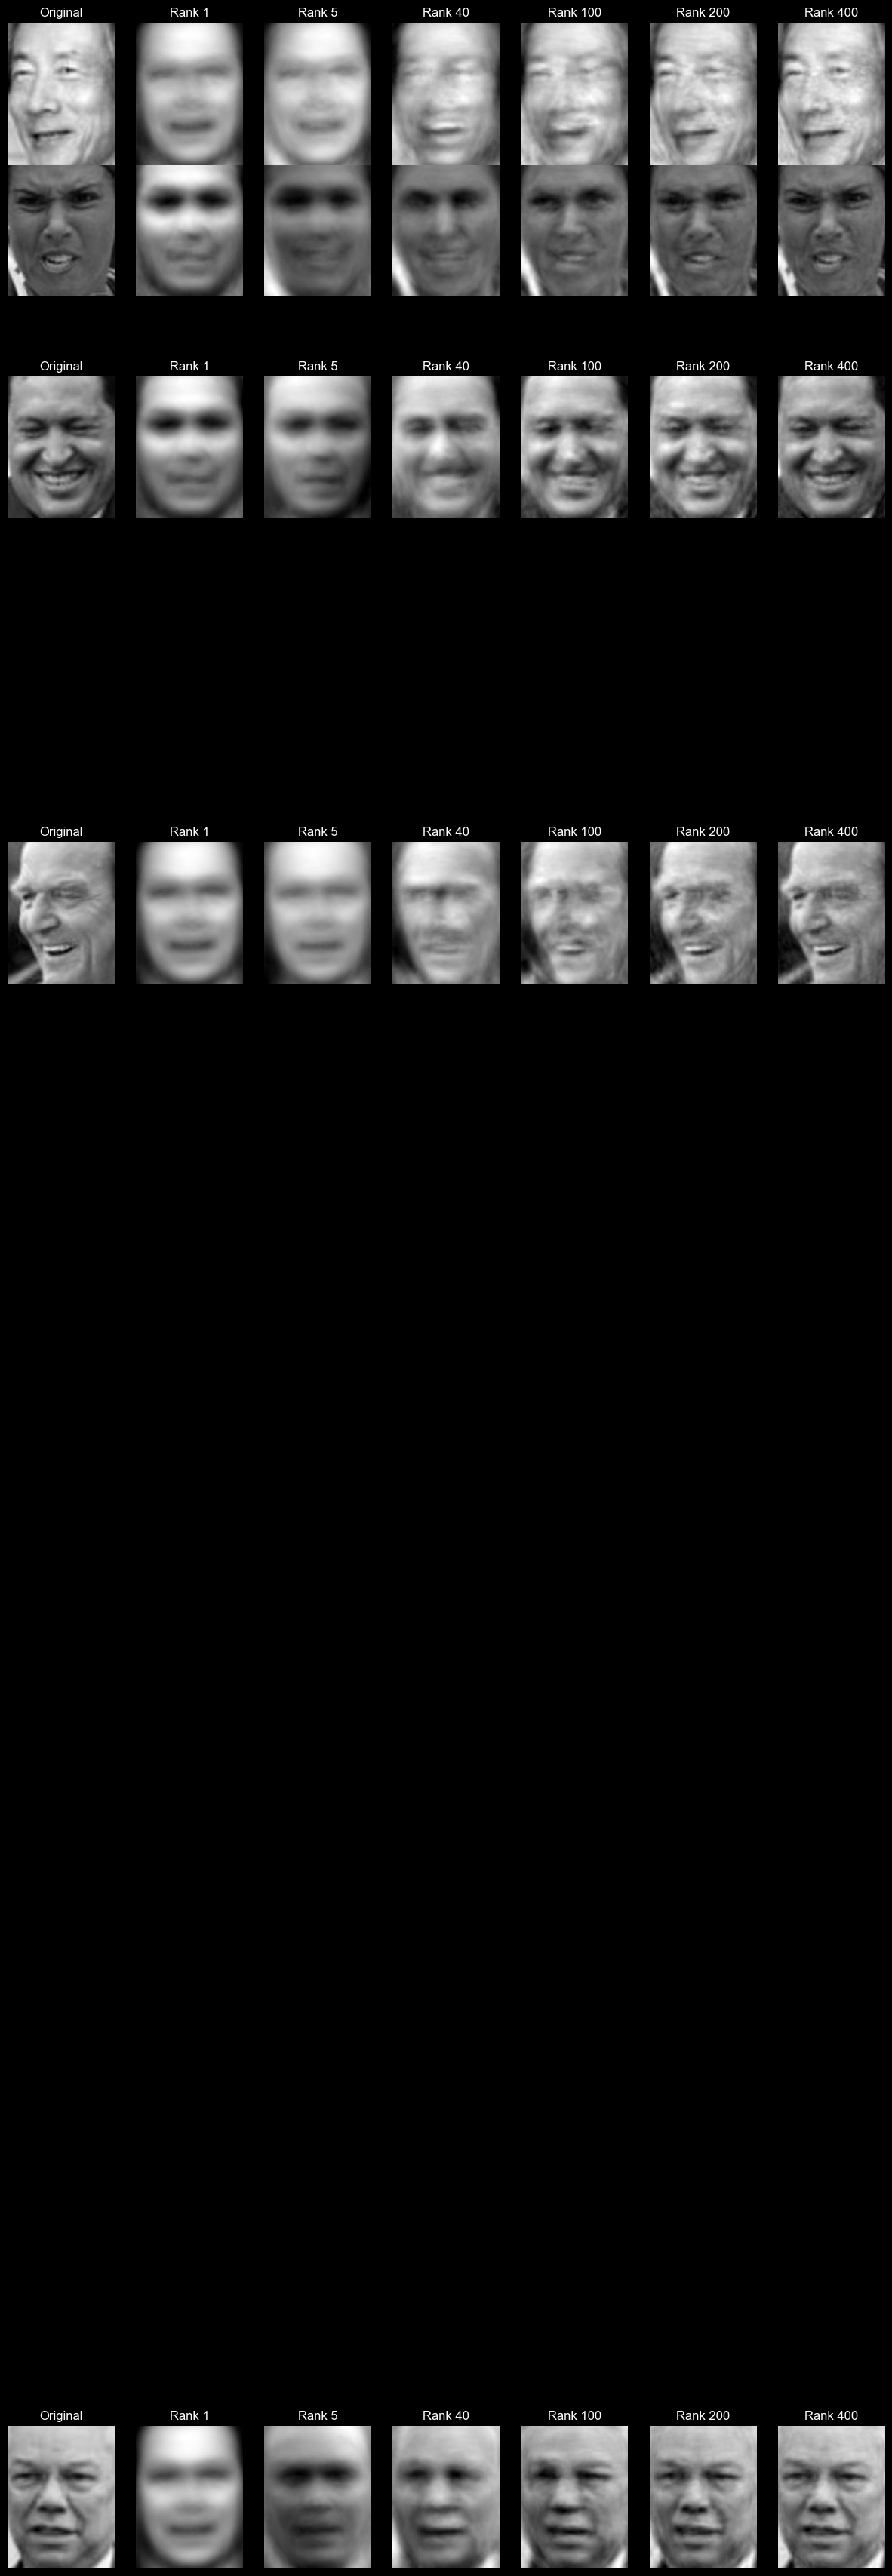

In [11]:
# ----------------------------------------------------
# Reconstruct specific faces to see visual quality
# ----------------------------------------------------
ranks_to_visualize = [1, 5, 40, 100, 200, 400]
n_visualize = len(ranks_to_visualize)

plt.figure(figsize=(15, 100))

for j in range(1,6):
    face_idx = j*100
    face_original = X[:, face_idx]
    # Plot original
    plt.subplot(j, n_visualize + 1, 1)
    plt.imshow(face_original.reshape((n_row, n_col)), cmap=plt.cm.gray)
    plt.title("Original")
    plt.axis('off')

    # Plot reconstructions
    for i, k in enumerate(ranks_to_visualize):
        reconstructed_face = ef_svd.reconstruct_dataset(X[:,face_idx:face_idx+1], k)
        plt.subplot(j, n_visualize + 1, i + 2)
        plt.imshow(reconstructed_face.reshape((n_row, n_col)), cmap=plt.cm.gray)
        plt.title(f"Rank {k}")
        plt.axis('off')

plt.show()

### Dimensionality Reduction for Classification
Let's evaluate whether eigenfaces retain enough information for classification while reducing the dimensionality. We will split the dataset into a training and test set using a stratified split to maintain the ratio of images per person.

In [5]:
from sklearn.model_selection import train_test_split

# Stratified split: 80% train, 20% test
# We also must transpose X back for train_test_split (which expects samples as rows),
# and then transpose the resulting sets back to (features, samples)
X_train, X_test, y_train, y_test = train_test_split(X.T, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_test = X_train.T, X_test.T

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# 1. Fit the EigenfacesSVD on the *training* data
# We must compute the mean face and eigenfaces using training only; test faces are centered with the training mean and projected onto the training eigenfaces.
ef_clf = EigenfacesSVD()
ef_clf.fit(X_train)

Training set shape: (11750, 608)
Test set shape: (11750, 152)
Shape of U: (11750, 608)
Shape of S: (608,)
Shape of Vt: (608, 608)


Accuracy on Raw Data: 0.4145
Accuracy on Compressed Data (70 dimensions): 0.4539


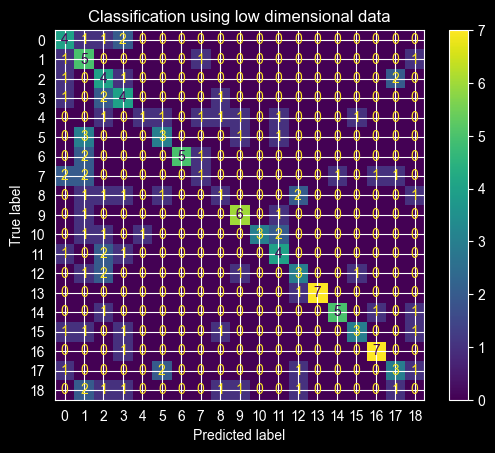

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# 2. Compress the training and test sets to 'k_components' dimensions (the projected weights)
# For training data, the weights are S_k * Vt_k since X = U S V^T, meaning weights w = U_k^T X = S_k Vt_k
# For test data, we have to center it using training mean_face and project it onto the top k eigenfaces (U_k^T).

k_components = 70

S_k = np.diag(ef_clf.S[:k_components])
Vt_k = ef_clf.Vt[:k_components, :]
X_train_compressed = S_k @ Vt_k

X_test_centered = X_test - ef_clf.mean_face
U_k = ef_clf.U[:, :k_components]
# Now we project the test faces into our first top k eigenfaces
X_test_compressed = U_k.T @ X_test_centered

# Transpose sets so samples are rows for scikit-learn classifiers
X_train_clf = X_train.T
X_test_clf = X_test.T
X_train_comp_clf = X_train_compressed.T
X_test_comp_clf = X_test_compressed.T

# 3. Train a 1-Nearest Neighbor classifier on the RAW training data
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train_clf, y_train)

# 4. Evaluate it on the RAW test data
y_pred_raw = knn_raw.predict(X_test_clf)
accuracy_raw = accuracy_score(y_test, y_pred_raw)

# 5. Train a 1-Nearest Neighbor classifier on the COMPRESSED training data
knn_compressed = KNeighborsClassifier(n_neighbors=5)
knn_compressed.fit(X_train_comp_clf, y_train)

# 6. Evaluate it on the COMPRESSED test data
y_pred_compressed = knn_compressed.predict(X_test_comp_clf)
accuracy_compressed = accuracy_score(y_test, y_pred_compressed)

print(f"Accuracy on Raw Data: {accuracy_raw:.4f}")
print(f"Accuracy on Compressed Data ({k_components} dimensions): {accuracy_compressed:.4f}")


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_compressed, labels=knn_compressed.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=knn_compressed.classes_)
disp.plot()
plt.title('Classification using low dimensional data')
plt.show()